<a href="https://colab.research.google.com/github/tejaswinimaddireddy678-web/smart-lender-project/blob/main/smart%20lender.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import sklearn
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV
import imblearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

In [3]:
#importing dataset which is in csv file
df=pd.read_csv("/content/drive/MyDrive/downl/Dataset.csv")
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


/tmp/ipykernel_8144/1462064872.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["ApplicantIncome"],color="r")
/tmp/ipykernel_8144/1462064872.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Credit_History"])


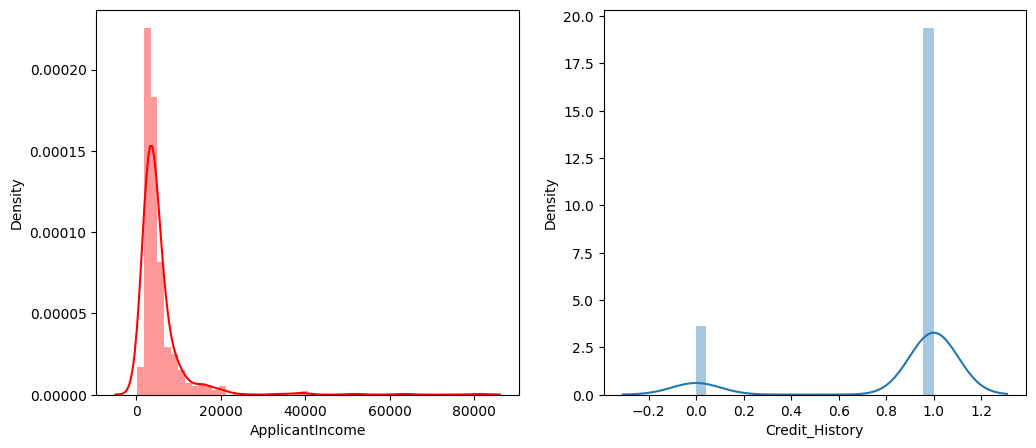

In [4]:
#Univarient Analysis
#plotting the using displot
plt.figure(figsize=(12,5))
plt.subplot(121)
sns.distplot(df["ApplicantIncome"],color="r")
plt.subplot(122)
sns.distplot(df["Credit_History"])
plt.show()

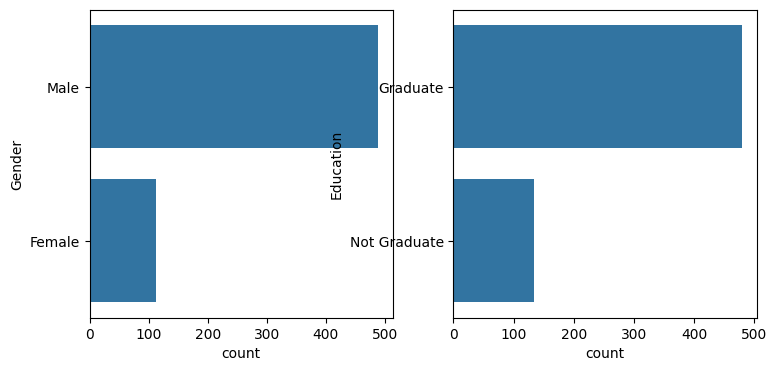

In [5]:
#Univarient Analysis
#plotting the using count plot
plt.figure(figsize=(18,4))
plt.subplot(1,4,1)
sns.countplot(df["Gender"])
plt.subplot(1,4,2)
sns.countplot(df["Education"])
plt.show()

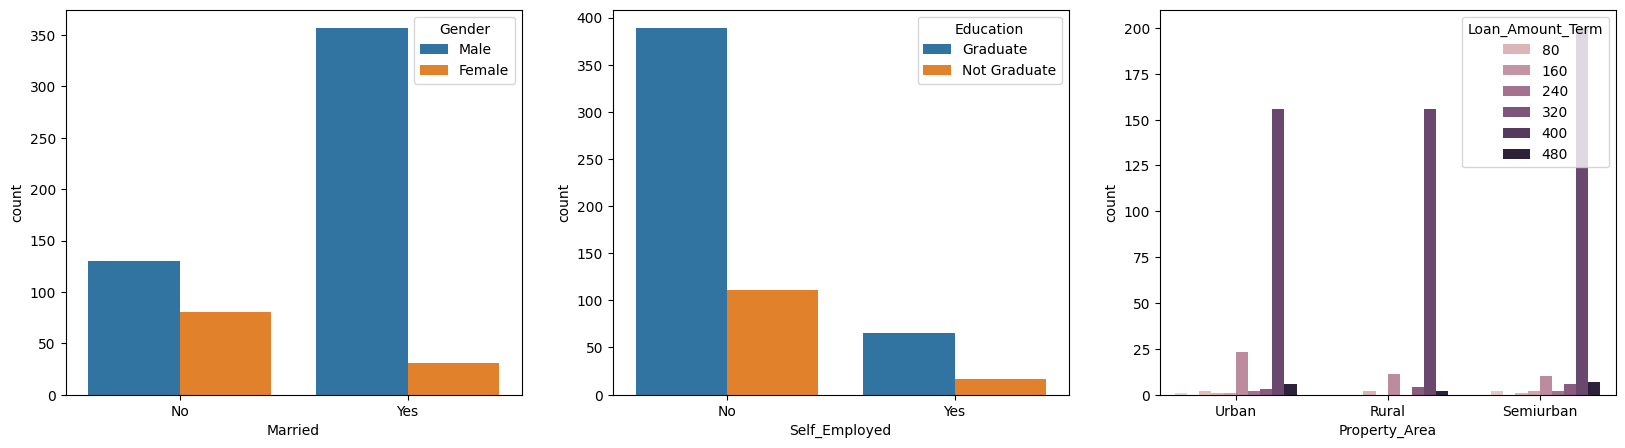

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
#Bivarient analysis
plt.figure(figsize=(20,5))
plt.subplot(131)
sns.countplot(x='Married', hue='Gender', data=df)
plt.subplot(132)
sns.countplot(x='Self_Employed', hue='Education', data=df)
plt.subplot(133)
sns.countplot(x='Property_Area', hue='Loan_Amount_Term', data=df)
plt.show()

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 45.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


<Axes: xlabel='Gender', ylabel='ApplicantIncome'>

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 61.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 25.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


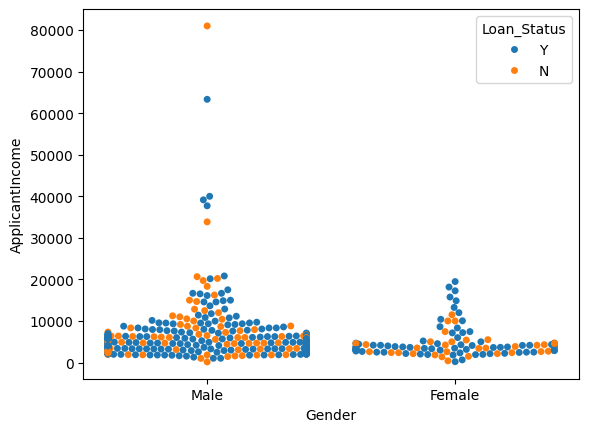

In [7]:
#Multivarient analysis
sns.swarmplot(x='Gender', y='ApplicantIncome', hue='Loan_Status', data=df)

In [8]:
#checking and handling missing values
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [10]:
categorical_columns = [
    'Gender',
    'Married',
    'Dependents',
    'Self_Employed',
    'Loan_Amount_Term',
    'Credit_History'
]

for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [11]:
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())

In [12]:
df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [13]:
# Prepare X and y for SMOTE
X = df.drop(columns=['Loan_ID', 'Loan_Status'])
y = df['Loan_Status'].map({'Y': 1, 'N': 0}) # Encode target variable

# Handle categorical features in X (one-hot encoding)
X = pd.get_dummies(X, drop_first=True)

# Import SMOTE and apply it
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
x_bal, y_bal = smote.fit_resample(X, y)

In [14]:
print(y.value_counts())
print(y_bal.value_counts())

Loan_Status
1    422
0    192
Name: count, dtype: int64
Loan_Status
1    422
0    422
Name: count, dtype: int64


In [16]:
names=X.columns

In [17]:
#scaling
sc=StandardScaler()
x_bal=sc.fit_transform(x_bal)
x_bal=pd.DataFrame(x_bal,columns=names)

In [18]:
import pickle

# Save the StandardScaler object
with open('standard_scaler.pkl', 'wb') as file:
    pickle.dump(sc, file)
print("StandardScaler saved as 'standard_scaler.pkl'")

StandardScaler saved as 'standard_scaler.pkl'


In [19]:
#splitting the data into training and testing datasets
x_train, x_test, y_train, y_test = train_test_split(x_bal, y_bal, test_size=0.2, random_state=42)

In [20]:
x_train.shape


(675, 14)

In [21]:
x_test.shape

(169, 14)

In [22]:
#Decision tree model
def decisionTree(x_train, x_test, y_train, y_test):
    # Initialize the classifier
    dt_model = DecisionTreeClassifier()
    # Train the model
    dt_model.fit(x_train, y_train)
    # Predict on test data
    y_pred = dt_model.predict(x_test)
    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(accuracy)

In [23]:
decisionTree(x_train, x_test, y_train, y_test)

0.7633136094674556


In [24]:
#Random forest
def run_RandomForestClassifier(x_train, x_test, y_train, y_test):
    # Initialize the classifier
    from sklearn.ensemble import RandomForestClassifier as RFClassifier
    dt_model = RFClassifier()
    # Train the model
    dt_model.fit(x_train, y_train)
    # Predict on test data
    y_pred = dt_model.predict(x_test)
    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(accuracy)
    return dt_model

model = run_RandomForestClassifier(x_train, x_test, y_train, y_test)

0.8224852071005917


In [25]:
def KNeighborsClassifier(x_train, x_test, y_train, y_test):
    # Initialize the classifier
    from sklearn.neighbors import KNeighborsClassifier as KNC
    dt_model = KNC()
    # Train the model
    dt_model.fit(x_train, y_train)
    # Predict on test data
    y_pred = dt_model.predict(x_test)
    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(accuracy)
KNeighborsClassifier(x_train, x_test, y_train, y_test)

0.6863905325443787


In [26]:
def XGB(x_train, x_test, y_train, y_test):
    # Initialize the classifier
    from sklearn.ensemble import GradientBoostingClassifier as GBC
    dt_model = GBC()
    # Train the model
    dt_model.fit(x_train, y_train)
    # Predict on test data
    y_pred = dt_model.predict(x_test)
    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Gradient Boosting Classifier Accuracy: {accuracy}")
    return dt_model
xgb_model = XGB(x_train, x_test, y_train, y_test)

Gradient Boosting Classifier Accuracy: 0.8047337278106509


In [27]:
import pickle

# Error: NameError: name 'model' is not defined.
# This usually means the Random Forest model (defined in cell 8AGAilq4fL5J) was not trained or executed before this cell.
# Please ensure the model training cell has been run successfully.
with open('random_forest_model.pkl', 'wb') as file:
    pickle.dump(model, file)
print("Random Forest model saved as 'random_forest_model.pkl'")

Random Forest model saved as 'random_forest_model.pkl'


In [28]:
# This usually means the Gradient Boosting model (defined in cell YegdrsTnf82f) was not trained or executed before this cell.
# Please ensure the model training cell has been run successfully.
with open('gradient_boosting_model.pkl', 'wb') as file:
    pickle.dump(xgb_model, file)
print("Gradient Boosting model saved as 'gradient_boosting_model.pkl'")

Gradient Boosting model saved as 'gradient_boosting_model.pkl'


In [29]:
import joblib

model = joblib.load("/content/random_forest_model.pkl")   # Use your actual model filename